# Analisis Pengaruh Viralitas Konten TikTok terhadap Popularitas Lagu di Spotify Menggunakan Machine Learning

**Prototype Skripsi — Data Mining & Machine Learning**

Notebook ini adalah *prototype* (purwarupa) dari sistem yang dijelaskan dalam judul skripsi. Prototype ini menunjukkan **alur kerja data mining (CRISP-DM)** secara lengkap:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling (Machine Learning)
5. Evaluation
6. Deployment (simulasi prediksi)

> **Catatan penting:** Karena skripsi belum menyertakan dataset asli hasil scraping TikTok API / Spotify API, notebook ini menggunakan **dataset simulasi (synthetic data)** yang polanya dibuat realistis (semakin viral di TikTok, semakin besar peluang lagu tersebut populer di Spotify, ditambah noise acak). Struktur kode ini **plug-and-play**: begitu Anda punya data asli (misalnya hasil scraping hashtag lagu di TikTok + data Spotify API), Anda tinggal mengganti fungsi `generate_dataset()` di bawah dengan proses pembacaan CSV/JSON asli, sisanya (EDA, preprocessing, model, evaluasi) tetap berjalan.


## 1. Business Understanding

**Rumusan masalah:** Apakah tingkat viralitas sebuah lagu di TikTok (jumlah video yang menggunakan lagu, views, likes, shares, comments, penggunaan hashtag challenge) berpengaruh terhadap tingkat popularitas lagu tersebut di Spotify (popularity score, jumlah streams)?

**Tujuan:**
- Mengetahui variabel viralitas TikTok yang paling berpengaruh terhadap popularitas Spotify (feature importance)
- Membangun model **regresi** untuk memprediksi *popularity score* Spotify (0-100) dari metrik TikTok
- Membangun model **klasifikasi** untuk memprediksi apakah sebuah lagu akan menjadi *'Hit'* atau *'Tidak Hit'* di Spotify

**Manfaat:** label/musisi/marketing tim dapat memperkirakan potensi sebuah lagu menjadi hit di Spotify berdasarkan performanya di TikTok, sehingga strategi promosi dapat difokuskan lebih awal.

In [1]:
# 1a. Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Library siap digunakan.")

Library siap digunakan.


## 2. Data Understanding

Dataset berisi metrik **TikTok** (fitur/independent variables) dan metrik **Spotify** (target/dependent variable) untuk sejumlah lagu.

| Kolom | Sumber | Keterangan |
|---|---|---|
| tiktok_video_count | TikTok | Jumlah video yang menggunakan lagu tsb |
| tiktok_views | TikTok | Total views dari video-video tsb |
| tiktok_likes | TikTok | Total likes |
| tiktok_shares | TikTok | Total shares |
| tiktok_comments | TikTok | Total komentar |
| tiktok_hashtag_challenge | TikTok | 1 jika lagu punya hashtag challenge sendiri, 0 jika tidak |
| days_since_release | Metadata | Umur lagu (hari) sejak dirilis |
| spotify_popularity | Spotify | Skor popularitas Spotify (0-100) — **target regresi** |
| spotify_streams | Spotify | Perkiraan jumlah streams |
| is_hit | Turunan | 1 jika spotify_popularity >= 70 — **target klasifikasi** |


In [2]:
def generate_dataset(n=600, seed=RANDOM_STATE):
    """
    Membuat dataset SIMULASI yang merepresentasikan hubungan antara
    viralitas TikTok dan popularitas Spotify.
    GANTI fungsi ini dengan pembacaan data asli (CSV hasil scraping
    TikTok Research API + Spotify Web API) saat data riil sudah tersedia.
    """
    rng = np.random.default_rng(seed)

    tiktok_video_count = rng.gamma(shape=2.0, scale=800, size=n).astype(int)
    tiktok_views = tiktok_video_count * rng.normal(15000, 4000, n).clip(min=500)
    tiktok_likes = tiktok_views * rng.uniform(0.05, 0.15, n)
    tiktok_shares = tiktok_likes * rng.uniform(0.05, 0.20, n)
    tiktok_comments = tiktok_likes * rng.uniform(0.01, 0.05, n)
    tiktok_hashtag_challenge = rng.binomial(1, 0.3, n)
    days_since_release = rng.integers(1, 900, n)

    # indeks viralitas gabungan (dipakai untuk MEMBANGKITKAN target,
    # bukan sebagai fitur langsung ke model -> menghindari data leakage)
    virality_index = (
        0.35 * (tiktok_video_count / tiktok_video_count.max())
        + 0.30 * (tiktok_views / tiktok_views.max())
        + 0.15 * (tiktok_likes / tiktok_likes.max())
        + 0.10 * (tiktok_shares / tiktok_shares.max())
        + 0.10 * tiktok_hashtag_challenge
    )

    noise = rng.normal(0, 0.08, n)
    popularity_raw = 100 * (virality_index + noise)
    spotify_popularity = np.clip(popularity_raw, 0, 100).round(1)
    spotify_streams = (spotify_popularity * rng.uniform(80_000, 250_000, n)).astype(int)

    df = pd.DataFrame({
        "song_id": [f"SG{i:04d}" for i in range(n)],
        "tiktok_video_count": tiktok_video_count,
        "tiktok_views": tiktok_views.astype(int),
        "tiktok_likes": tiktok_likes.astype(int),
        "tiktok_shares": tiktok_shares.astype(int),
        "tiktok_comments": tiktok_comments.astype(int),
        "tiktok_hashtag_challenge": tiktok_hashtag_challenge,
        "days_since_release": days_since_release,
        "spotify_popularity": spotify_popularity,
        "spotify_streams": spotify_streams,
    })
    # Ambang batas "Hit" berbasis kuantil (top ~30% lagu terpopuler)
    # agar kelas tetap cukup seimbang untuk klasifikasi.
    threshold = np.quantile(spotify_popularity, 0.70)
    df["is_hit"] = (df["spotify_popularity"] >= threshold).astype(int)
    return df

df = generate_dataset()
df.to_csv("dataset_tiktok_spotify.csv", index=False)
print("Dataset dibuat:", df.shape)
df.head()

Dataset dibuat: (600, 11)


,song_id,tiktok_video_count,tiktok_views,tiktok_likes,tiktok_shares,tiktok_comments,tiktok_hashtag_challenge,days_since_release,spotify_popularity,spotify_streams,is_hit
0,SG0000,1673,18012983,1202123,146907,48061,0,476,6.1,1462287,0
1,SG0001,2268,22021906,2481074,336769,121612,1,646,32.3,3273962,1
2,SG0002,1469,19178123,1584570,90892,45063,0,379,0.0,0,0
3,SG0003,1316,21952073,2505963,277263,89465,0,237,14.9,2835529,0
4,SG0004,2463,35936187,3278309,450592,153249,0,412,17.2,3520727,0


In [3]:
# Statistik deskriptif
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tiktok_video_count,600.0,1.574270e+03,1.110277e+03,74.0,7.822500e+02,1345.0,2099.75,8048.0
tiktok_views,600.0,2.328414e+07,1.860932e+07,1028723.0,1.042967e+07,18040031.5,31470165.75,119369107.0
tiktok_likes,600.0,2.333380e+06,2.118584e+06,58382.0,9.254502e+05,1698057.0,2910166.25,13596821.0
tiktok_shares,600.0,2.911407e+05,3.029022e+05,4676.0,1.020968e+05,199091.5,365414.25,2289286.0
tiktok_comments,600.0,7.117840e+04,7.566202e+04,758.0,2.296625e+04,44878.0,90954.50,570892.0
tiktok_hashtag_challenge,600.0,2.750000e-01,4.468868e-01,0.0,0.000000e+00,0.0,1.00,1.0
days_since_release,600.0,4.597700e+02,2.640507e+02,3.0,2.312500e+02,466.5,690.00,899.0
spotify_popularity,600.0,1.921017e+01,1.489777e+01,0.0,8.375000e+00,16.6,28.10,86.3
spotify_streams,600.0,3.111319e+06,2.730778e+06,0.0,1.200124e+06,2503018.5,4379781.25,18420176.0
is_hit,600.0,3.016667e-01,4.593643e-01,0.0,0.000000e+00,0.0,1.00,1.0


In [4]:
# Cek missing value & tipe data
print(df.info())
print("\nJumlah missing value per kolom:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   song_id                   600 non-null    str    
 1   tiktok_video_count        600 non-null    int64  
 2   tiktok_views              600 non-null    int64  
 3   tiktok_likes              600 non-null    int64  
 4   tiktok_shares             600 non-null    int64  
 5   tiktok_comments           600 non-null    int64  
 6   tiktok_hashtag_challenge  600 non-null    int64  
 7   days_since_release        600 non-null    int64  
 8   spotify_popularity        600 non-null    float64
 9   spotify_streams           600 non-null    int64  
 10  is_hit                    600 non-null    int64  
dtypes: float64(1), int64(9), str(1)
memory usage: 51.7 KB
None

Jumlah missing value per kolom:
song_id                     0
tiktok_video_count          0
tiktok_views                0
tikt

### Exploratory Data Analysis (EDA)

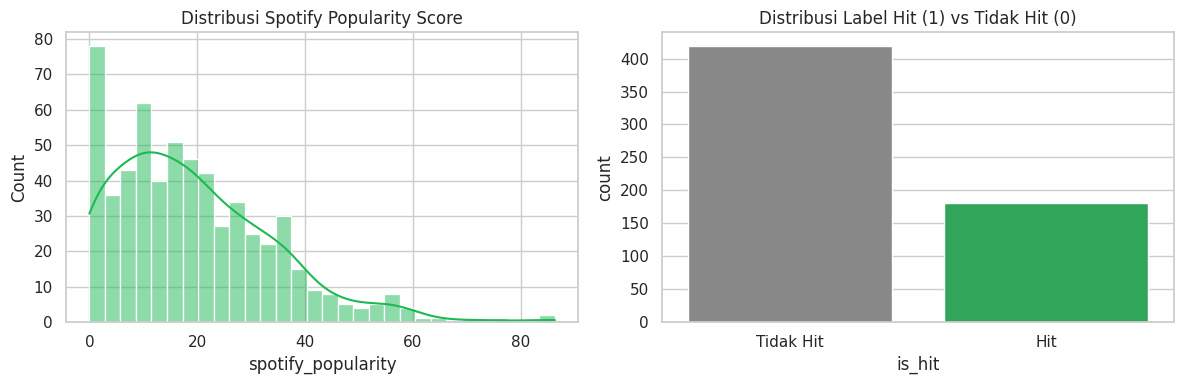

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["spotify_popularity"], bins=30, kde=True, ax=axes[0], color="#1DB954")
axes[0].set_title("Distribusi Spotify Popularity Score")
sns.countplot(x="is_hit", data=df, hue="is_hit", ax=axes[1], palette=["#888888", "#1DB954"], legend=False)
axes[1].set_title("Distribusi Label Hit (1) vs Tidak Hit (0)")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Tidak Hit", "Hit"])
plt.tight_layout()
plt.savefig("eda_distribusi.png", bbox_inches="tight")
plt.show()

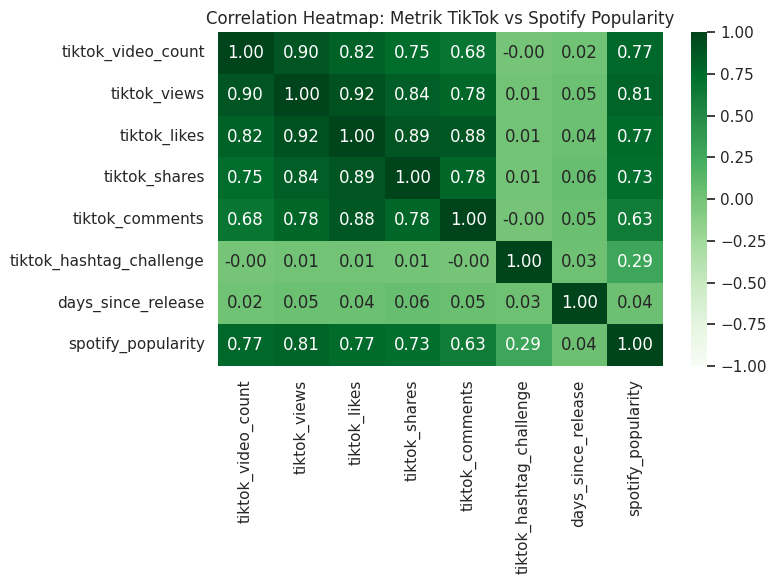

In [6]:
numeric_cols = ["tiktok_video_count", "tiktok_views", "tiktok_likes", "tiktok_shares",
                "tiktok_comments", "tiktok_hashtag_challenge", "days_since_release",
                "spotify_popularity"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Greens", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Metrik TikTok vs Spotify Popularity")
plt.tight_layout()
plt.savefig("eda_korelasi.png", bbox_inches="tight")
plt.show()

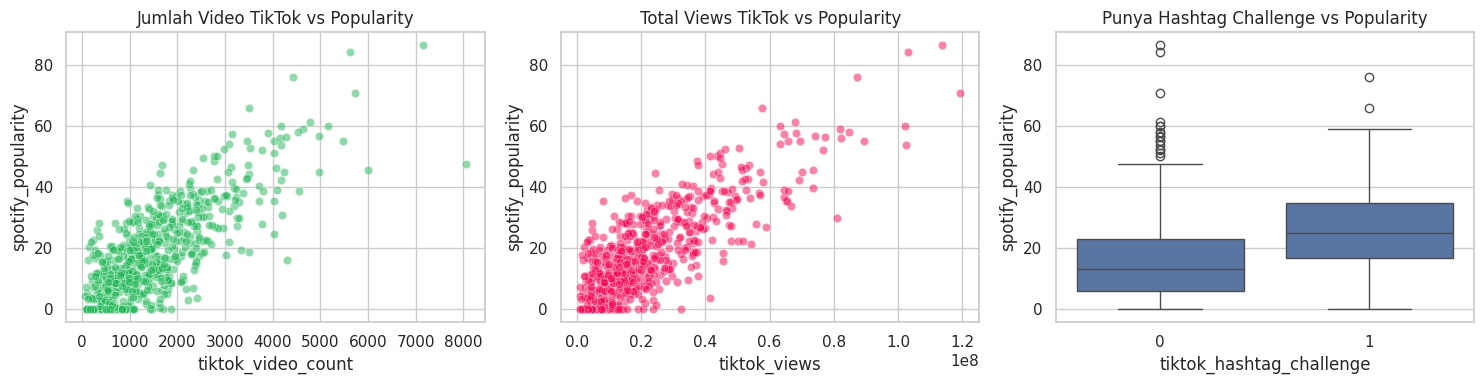

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x="tiktok_video_count", y="spotify_popularity", data=df, alpha=0.5, ax=axes[0], color="#1DB954")
axes[0].set_title("Jumlah Video TikTok vs Popularity")
sns.scatterplot(x="tiktok_views", y="spotify_popularity", data=df, alpha=0.5, ax=axes[1], color="#ff0050")
axes[1].set_title("Total Views TikTok vs Popularity")
sns.boxplot(x="tiktok_hashtag_challenge", y="spotify_popularity", data=df, ax=axes[2])
axes[2].set_title("Punya Hashtag Challenge vs Popularity")
plt.tight_layout()
plt.savefig("eda_scatter.png", bbox_inches="tight")
plt.show()

## 3. Data Preparation

Tahap ini meliputi: *feature engineering* (membuat fitur turunan yang lebih informatif seperti engagement rate), penanganan outlier/skew dengan transformasi, scaling, serta pembagian data latih dan uji.

In [8]:
# Feature engineering
df_fe = df.copy()
df_fe["engagement_rate"] = (df_fe["tiktok_likes"] + df_fe["tiktok_shares"] + df_fe["tiktok_comments"]) / df_fe["tiktok_views"]
df_fe["like_per_video"] = df_fe["tiktok_likes"] / df_fe["tiktok_video_count"]
df_fe["share_rate"] = df_fe["tiktok_shares"] / df_fe["tiktok_views"]

# Fitur numerik berskala besar -> transformasi log agar distribusi lebih baik
for col in ["tiktok_video_count", "tiktok_views", "tiktok_likes", "tiktok_shares", "tiktok_comments"]:
    df_fe[f"log_{col}"] = np.log1p(df_fe[col])

feature_cols = [
    "log_tiktok_video_count", "log_tiktok_views", "log_tiktok_likes",
    "log_tiktok_shares", "log_tiktok_comments", "tiktok_hashtag_challenge",
    "days_since_release", "engagement_rate", "like_per_video", "share_rate",
]

X = df_fe[feature_cols]
y_reg = df_fe["spotify_popularity"]          # target regresi
y_clf = df_fe["is_hit"]                      # target klasifikasi

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Jumlah fitur:", len(feature_cols))
print("Data latih:", X_train.shape, "| Data uji:", X_test.shape)

Jumlah fitur: 10
Data latih: (480, 10) | Data uji: (120, 10)


## 4. Modeling

Dua model **Random Forest** dibangun:
1. **Regressor** → memprediksi *spotify_popularity* (skor 0-100)
2. **Classifier** → memprediksi *is_hit* (Hit / Tidak Hit)

Random Forest dipilih karena tahan terhadap non-linearitas, tidak butuh scaling ketat, dan menyediakan *feature importance* yang mudah diinterpretasikan untuk menjawab rumusan masalah.

In [9]:
# Model Regresi
reg_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
reg_model.fit(X_train, y_reg_train)
y_reg_pred = reg_model.predict(X_test)
print("Model regresi selesai dilatih.")

Model regresi selesai dilatih.


In [10]:
# Model Klasifikasi
clf_model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, class_weight="balanced")
clf_model.fit(X_train, y_clf_train)
y_clf_pred = clf_model.predict(X_test)
print("Model klasifikasi selesai dilatih.")

Model klasifikasi selesai dilatih.


## 5. Evaluation

=== Evaluasi Model Regresi (prediksi Spotify Popularity) ===
MAE  : 5.99
RMSE : 7.53
R2   : 0.698


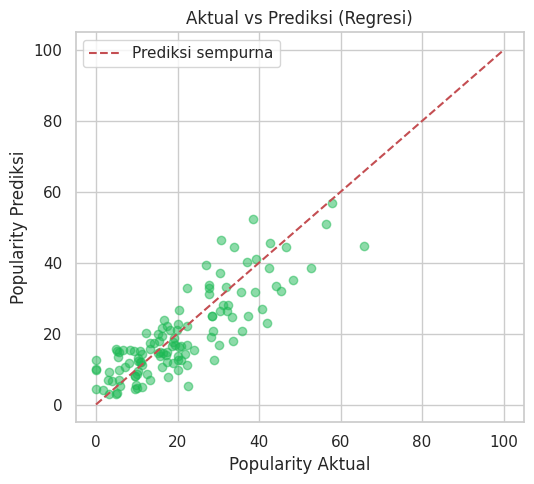

In [11]:
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = mean_squared_error(y_reg_test, y_reg_pred) ** 0.5
r2 = r2_score(y_reg_test, y_reg_pred)

print("=== Evaluasi Model Regresi (prediksi Spotify Popularity) ===")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.3f}")

plt.figure(figsize=(5.5, 5))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.5, color="#1DB954")
plt.plot([0, 100], [0, 100], "r--", label="Prediksi sempurna")
plt.xlabel("Popularity Aktual")
plt.ylabel("Popularity Prediksi")
plt.title("Aktual vs Prediksi (Regresi)")
plt.legend()
plt.tight_layout()
plt.savefig("eval_regresi.png", bbox_inches="tight")
plt.show()

=== Evaluasi Model Klasifikasi (prediksi Hit / Tidak Hit) ===
Accuracy  : 0.925
Precision : 0.969
Recall    : 0.795
F1-score  : 0.873

              precision    recall  f1-score   support

   Tidak Hit       0.91      0.99      0.95        81
         Hit       0.97      0.79      0.87        39

    accuracy                           0.93       120
   macro avg       0.94      0.89      0.91       120
weighted avg       0.93      0.93      0.92       120



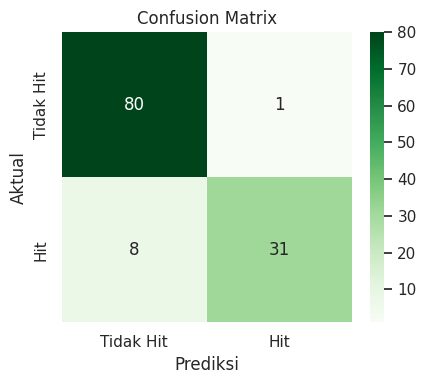

In [12]:
acc = accuracy_score(y_clf_test, y_clf_pred)
prec = precision_score(y_clf_test, y_clf_pred, zero_division=0)
rec = recall_score(y_clf_test, y_clf_pred, zero_division=0)
f1 = f1_score(y_clf_test, y_clf_pred, zero_division=0)

print("=== Evaluasi Model Klasifikasi (prediksi Hit / Tidak Hit) ===")
print(f"Accuracy  : {acc:.3f}")
print(f"Precision : {prec:.3f}")
print(f"Recall    : {rec:.3f}")
print(f"F1-score  : {f1:.3f}")
print()
print(classification_report(y_clf_test, y_clf_pred, labels=[0, 1], target_names=["Tidak Hit", "Hit"], zero_division=0))

cm = confusion_matrix(y_clf_test, y_clf_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Tidak Hit", "Hit"], yticklabels=["Tidak Hit", "Hit"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("eval_confusion_matrix.png", bbox_inches="tight")
plt.show()

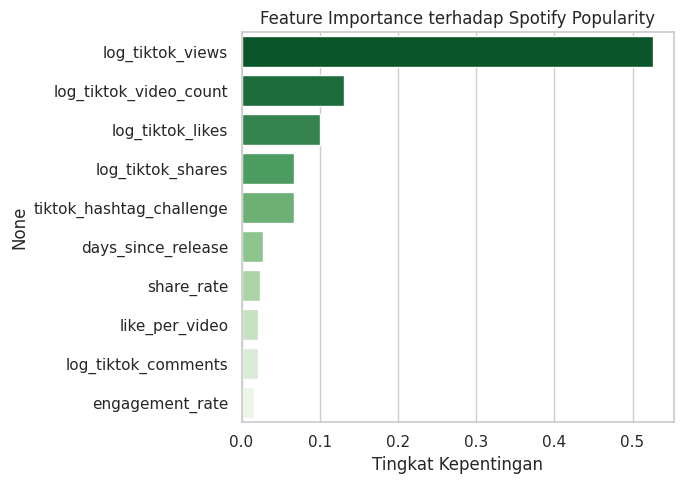

log_tiktok_views            0.526697
log_tiktok_video_count      0.131012
log_tiktok_likes            0.100825
log_tiktok_shares           0.066837
tiktok_hashtag_challenge    0.066706
days_since_release          0.027533
share_rate                  0.023223
like_per_video              0.021102
log_tiktok_comments         0.020563
engagement_rate             0.015503
dtype: float64

In [13]:
# Feature Importance -> menjawab rumusan masalah: fitur TikTok mana paling berpengaruh
importances = pd.Series(reg_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="Greens_r", legend=False)
plt.title("Feature Importance terhadap Spotify Popularity")
plt.xlabel("Tingkat Kepentingan")
plt.tight_layout()
plt.savefig("eval_feature_importance.png", bbox_inches="tight")
plt.show()

importances

## 6. Deployment — Simulasi Prototype Prediksi

Bagian ini mensimulasikan bagaimana prototype akan digunakan oleh pengguna akhir (misalnya tim promosi/label rekaman): memasukkan metrik performa TikTok sebuah lagu baru, lalu sistem memprediksi skor popularitas Spotify dan status Hit/Tidak Hit.

In [14]:
def predict_song_popularity(video_count, views, likes, shares, comments,
                             hashtag_challenge, days_since_release):
    """Fungsi prototype: input metrik TikTok mentah -> output prediksi Spotify."""
    raw = pd.DataFrame([{
        "tiktok_video_count": video_count, "tiktok_views": views, "tiktok_likes": likes,
        "tiktok_shares": shares, "tiktok_comments": comments,
    }])
    engagement_rate = (likes + shares + comments) / views
    like_per_video = likes / video_count
    share_rate = shares / views

    row = {
        "log_tiktok_video_count": np.log1p(video_count),
        "log_tiktok_views": np.log1p(views),
        "log_tiktok_likes": np.log1p(likes),
        "log_tiktok_shares": np.log1p(shares),
        "log_tiktok_comments": np.log1p(comments),
        "tiktok_hashtag_challenge": hashtag_challenge,
        "days_since_release": days_since_release,
        "engagement_rate": engagement_rate,
        "like_per_video": like_per_video,
        "share_rate": share_rate,
    }
    X_new = pd.DataFrame([row])[feature_cols]

    pred_popularity = reg_model.predict(X_new)[0]
    pred_hit_proba = clf_model.predict_proba(X_new)[0][1]
    pred_hit_label = "HIT" if clf_model.predict(X_new)[0] == 1 else "TIDAK HIT"

    print(f"Prediksi Spotify Popularity : {pred_popularity:.1f} / 100")
    print(f"Probabilitas menjadi Hit    : {pred_hit_proba*100:.1f}%")
    print(f"Status prediksi             : {pred_hit_label}")
    return pred_popularity, pred_hit_proba, pred_hit_label

# Contoh: lagu baru yang sedang naik daun di TikTok
print("Contoh 1 — Lagu dengan performa TikTok tinggi:")
predict_song_popularity(video_count=50000, views=800_000_000, likes=95_000_000,
                         shares=18_000_000, comments=3_500_000,
                         hashtag_challenge=1, days_since_release=30)

print("\nContoh 2 — Lagu dengan performa TikTok rendah:")
predict_song_popularity(video_count=200, views=1_200_000, likes=90_000,
                         shares=8_000, comments=1_200,
                         hashtag_challenge=0, days_since_release=200)

Contoh 1 — Lagu dengan performa TikTok tinggi:
Prediksi Spotify Popularity : 78.8 / 100
Probabilitas menjadi Hit    : 94.3%
Status prediksi             : HIT

Contoh 2 — Lagu dengan performa TikTok rendah:
Prediksi Spotify Popularity : 2.8 / 100
Probabilitas menjadi Hit    : 0.7%
Status prediksi             : TIDAK HIT


(np.float64(2.763529714387558), np.float64(0.007091576185648399), 'TIDAK HIT')

## 7. Kesimpulan Prototype

Prototype ini menunjukkan alur *data mining* lengkap yang relevan dengan judul skripsi:

- **Data Understanding & Preparation**: mengidentifikasi metrik viralitas TikTok (video count, views, likes, shares, comments, hashtag challenge) sebagai fitur, dan membangun fitur turunan (engagement rate) yang lebih informatif.
- **Modeling**: dua pendekatan machine learning (regresi dan klasifikasi) menggunakan Random Forest untuk menjawab dua sudut pandang masalah — skor popularitas dan status hit.
- **Evaluation**: metrik standar (MAE, RMSE, R² untuk regresi; Accuracy, Precision, Recall, F1 untuk klasifikasi) digunakan agar hasil dapat dipertanggungjawabkan secara akademis.
- **Feature Importance** menjawab langsung rumusan masalah skripsi: metrik TikTok mana yang paling berpengaruh terhadap popularitas Spotify.
- **Deployment**: fungsi `predict_song_popularity()` mensimulasikan bagaimana sistem ini bisa dipakai di dunia nyata sebagai *decision-support tool*.

### Langkah pengembangan selanjutnya (untuk skripsi final)
1. Ganti `generate_dataset()` dengan data asli: scraping TikTok (TikTok Research API / tools pihak ketiga seperti `TikTokApi`) dan Spotify Web API (`spotipy`) untuk lagu-lagu nyata.
2. Lakukan uji coba beberapa algoritma lain (XGBoost, Gradient Boosting, Linear/Logistic Regression) sebagai pembanding (*benchmarking model*).
3. Tambahkan validasi silang (*k-fold cross validation*) dan *hyperparameter tuning* (GridSearchCV) untuk hasil yang lebih robust.
4. Pertimbangkan aspek time-series (tren viralitas dari waktu ke waktu), bukan hanya snapshot data.
